In [1]:
import pandas as pd
import os
import subprocess
from glob import glob
import duckdb
import os
import tempfile
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

# Preparing c curve commands
C curve generates the seen complexity curve.

In [2]:
# Path to your preseq binary in the conda env
preseq_bin = (
    "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq"
)

# # Base directory containing umi_* folders
# BASE_DIR = "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/"

# # Find all umi_* directories
# umi_dirs = sorted(glob(os.path.join(BASE_DIR, "*RPTR*")))

# print(f"Found {len(umi_dirs)} UMI directories")
umi_dirs = ['/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_fastp',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_fastp',]
umi_dirs

['/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_fastp',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_fastp']

In [3]:
#1_30 and 1_5

In [4]:
# Loop over directories and print preseq commands
for umi_dir in umi_dirs:
    input_file = os.path.join(umi_dir, "preseq_input.txt")
    output_file = os.path.join(umi_dir, "preseq_yield_c_curve.txt")

    if not os.path.exists(input_file):
        print(f"Missing input: {input_file}")
        continue

    # Check if the input file is not empty
    if os.path.getsize(input_file) == 0:
        continue

    cmd = f"{preseq_bin} c_curve -V {input_file} -o {output_file}"
    print(f"{cmd}")

/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq c_curve -V /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_fastp/preseq_input.txt -o /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_fastp/preseq_yield_c_curve.txt
/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq c_curve -V /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_fastp/preseq_input.txt -o /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_fastp/preseq_yield_c_curve.txt


# Plotting complexity curves

In [9]:
curve_output_t30 = "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_fastp/preseq_yield_c_curve.txt"
curve_df_t30 = pd.read_csv(curve_output_t30, sep = "\t")
curve_df_t30

,total_reads,distinct_reads
0,0,0.0
1,1000000,933833.0
2,2000000,1752320.0
3,3000000,2473290.0
4,4000000,3111300.0
...,...,...
495,495000000,26267800.0
496,496000000,26296800.0
497,497000000,26325700.0
498,498000000,26354500.0


In [10]:
curve_output_t5 = "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_fastp/preseq_yield_c_curve.txt"
curve_df_t5 = pd.read_csv(curve_output_t5, sep = "\t")
curve_df_t5

,total_reads,distinct_reads
0,0,0.0
1,1000000,679643.0
2,2000000,1006750.0
3,3000000,1188240.0
4,4000000,1303420.0
...,...,...
256,256000000,7985220.0
257,257000000,8007290.0
258,258000000,8029350.0
259,259000000,8051400.0


Text(0.5, 1.0, 'GCN4 RT: Preseq Complexity Curve')

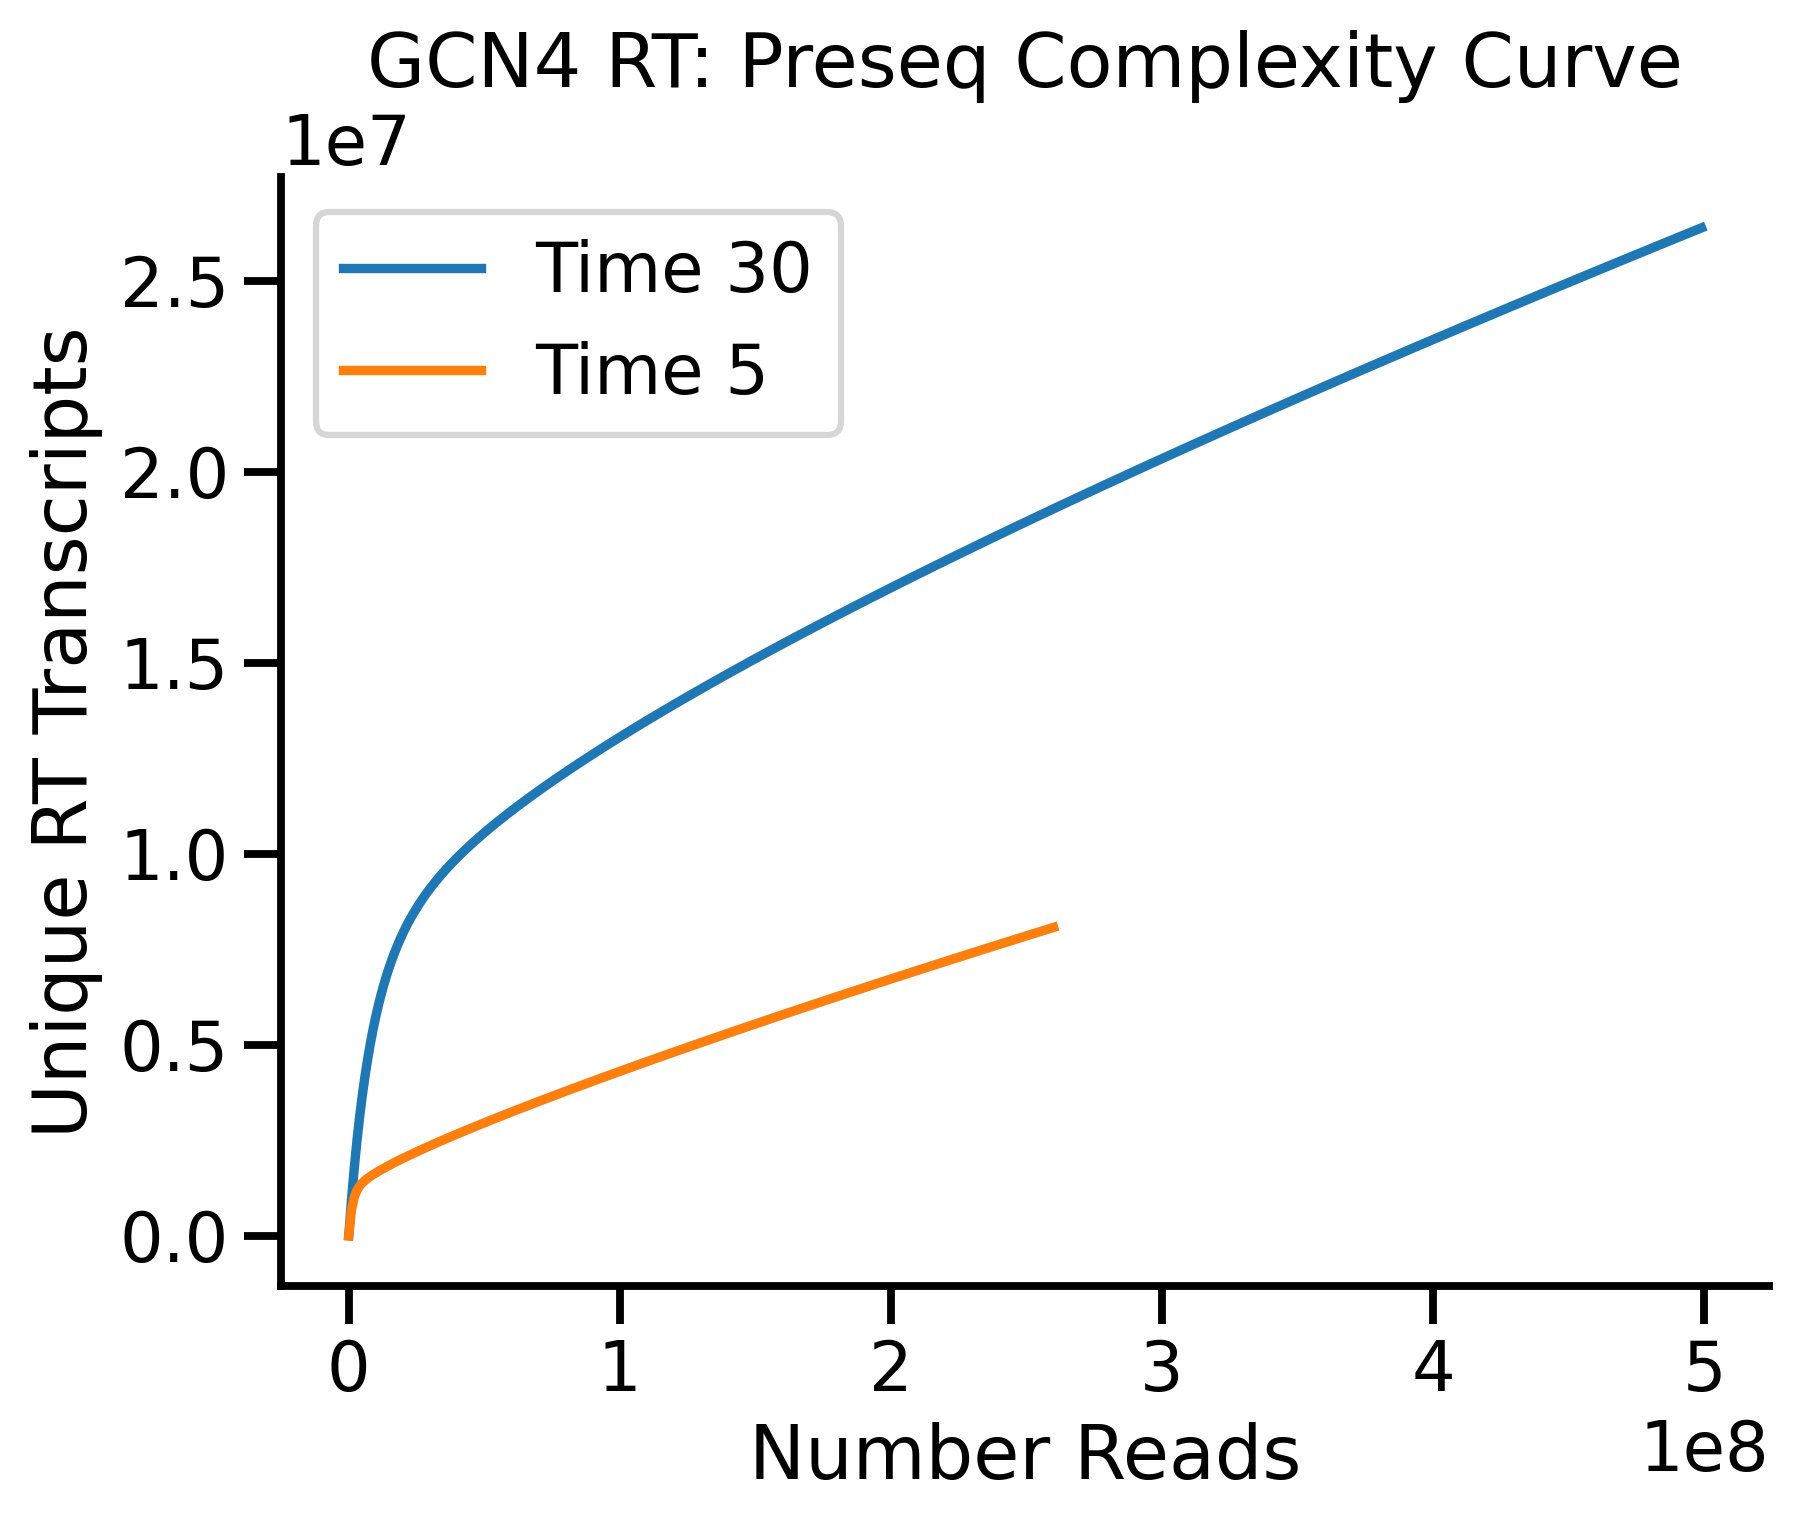

In [7]:
sns.set_context('talk')
plt.figure(dpi = 300)
sns.lineplot(data = curve_df_t30, x = "total_reads", y = "distinct_reads", label='Time 30')
sns.lineplot(data = curve_df_t5, x = "total_reads", y = "distinct_reads", label = 'Time 5')
sns.despine()
plt.xlabel("Number Reads")
plt.ylabel("Unique RT Transcripts")
plt.title("GCN4 RT: Preseq Complexity Curve")

# LC curve from small sample

In [49]:
for file_path in glob("../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_*_5_chunks_part_1/*umi.tsv"):
    print(file_path)

    out_file = os.path.join(os.path.dirname(file_path), "preseq_input.txt")

    # Create a temporary DuckDB file on scratch
    with tempfile.TemporaryDirectory() as tmpdir:
        db_path = os.path.join(tmpdir, "temp.duckdb")
        con = duckdb.connect(db_path)

        # Optional but recommended on HPC
        con.execute("PRAGMA threads=40;")
        con.execute("PRAGMA temp_directory='" + tmpdir + "';")

        con.execute(
            f"""
            COPY (
                SELECT
                    SUM(reads) AS reads
                FROM read_csv(
                    '{file_path}',
                    sep='\t',
                    header=true,
                    columns={{
                        'RPTR_BC': 'VARCHAR',
                        'UMI': 'VARCHAR',
                        'reads': 'BIGINT'
                    }}
                )
                GROUP BY RPTR_BC, UMI
            )
            TO '{out_file}'
            (HEADER false);
        """
        )

        con.close()


../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_5_chunks_part_1/RPTR_1_5_S2_R1_001_5_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_5_chunks_part_1/RPTR_1_30_S5_R1_001_5_chunks_part_1.fq_reads_per_umi.tsv


In [50]:
# Loop over directories and print preseq commands
for umi_dir in ["/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_5_chunks_part_1/",
                "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_5_chunks_part_1/"]:
    input_file = os.path.join(umi_dir, "preseq_input.txt")
    output_file = os.path.join(umi_dir, "preseq_yield_lc_extrap.txt")

    if not os.path.exists(input_file):
        print(f"Missing input: {input_file}")
        continue

    # Check if the input file is not empty
    if os.path.getsize(input_file) == 0:
        continue

    cmd = f"{preseq_bin} lc_extrap -V {input_file} -o {output_file}"
    print(f"{cmd}")

/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq lc_extrap -V /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_5_chunks_part_1/preseq_input.txt -o /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_5_chunks_part_1/preseq_yield_lc_extrap.txt
/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq lc_extrap -V /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_5_chunks_part_1/preseq_input.txt -o /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_5_chunks_part_1/preseq_yield_lc_extrap.txt


In [48]:
def plot_preseq_comparison(chunks, plot_obs, fig, ax):
    chunk_curve_output_t30 = (
        f"/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/downsampling/"
        f"trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_{chunks}_chunks_part_1/"
        "preseq_yield_lc_extrap.txt"
    )
    chunk_curve_df_t30 = pd.read_csv(chunk_curve_output_t30, sep="\t")
    chunk_curve_df_t30 = chunk_curve_df_t30[
        chunk_curve_df_t30["TOTAL_READS"] < 0.75 * 10**10
    ]

    chunk_curve_output_t5 = (
        f"/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/downsampling/"
        f"trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_{chunks}_chunks_part_1/"
        "preseq_yield_lc_extrap.txt"
    )
    chunk_curve_df_t5 = pd.read_csv(chunk_curve_output_t5, sep="\t")
    chunk_curve_df_t5 = chunk_curve_df_t5[
        chunk_curve_df_t5["TOTAL_READS"] < 0.75 * 10**10
    ]

    # Predicted curves
    sns.lineplot(
        data=chunk_curve_df_t30,
        x="TOTAL_READS",
        y="EXPECTED_DISTINCT",
        color="C0",
        linestyle="dashed",
        alpha=0.25,
        ax=ax,
        label= "T30 Preseq"
    )
    ax.fill_between(
        chunk_curve_df_t30["TOTAL_READS"],
        chunk_curve_df_t30["LOWER_0.95CI"],
        chunk_curve_df_t30["UPPER_0.95CI"],
        alpha=0.23,
        color="C0",
    )

    sns.lineplot(
        data=chunk_curve_df_t5,
        x="TOTAL_READS",
        y="EXPECTED_DISTINCT",
        color="C1",
        linestyle="dashed",
        alpha=0.25,
        ax=ax,
        label= "T5 Preseq"
    )
    ax.fill_between(
        chunk_curve_df_t5["TOTAL_READS"],
        chunk_curve_df_t5["LOWER_0.95CI"],
        chunk_curve_df_t5["UPPER_0.95CI"],
        alpha=0.23,
        color="C1",
    )



    if plot_obs:
        # Observed curves (assumes curve_df_t5 / curve_df_t30 exist in scope)
        sns.lineplot(
            data=curve_df_t5,
            x="total_reads",
            y="distinct_reads",
            label="T5 Obs.",
            color="C1",
            ax=ax,
            lw = 3
        )
        sns.lineplot(
            data=curve_df_t30,
            x="total_reads",
            y="distinct_reads",
            label="T30 Obs.",
            color="C0",
            ax=ax,
            lw = 3
        )

    ax.set_title(f"{100 / chunks}% of reads")
    ax.set_xlabel("Total Reads")
    ax.set_ylabel("Unique RT Transcripts")
    ax.legend(loc="upper right", bbox_to_anchor=(1.5, 1))
    sns.despine(ax=ax)

    return ax

Text(0.5, 0.98, 'Preseq Performance')

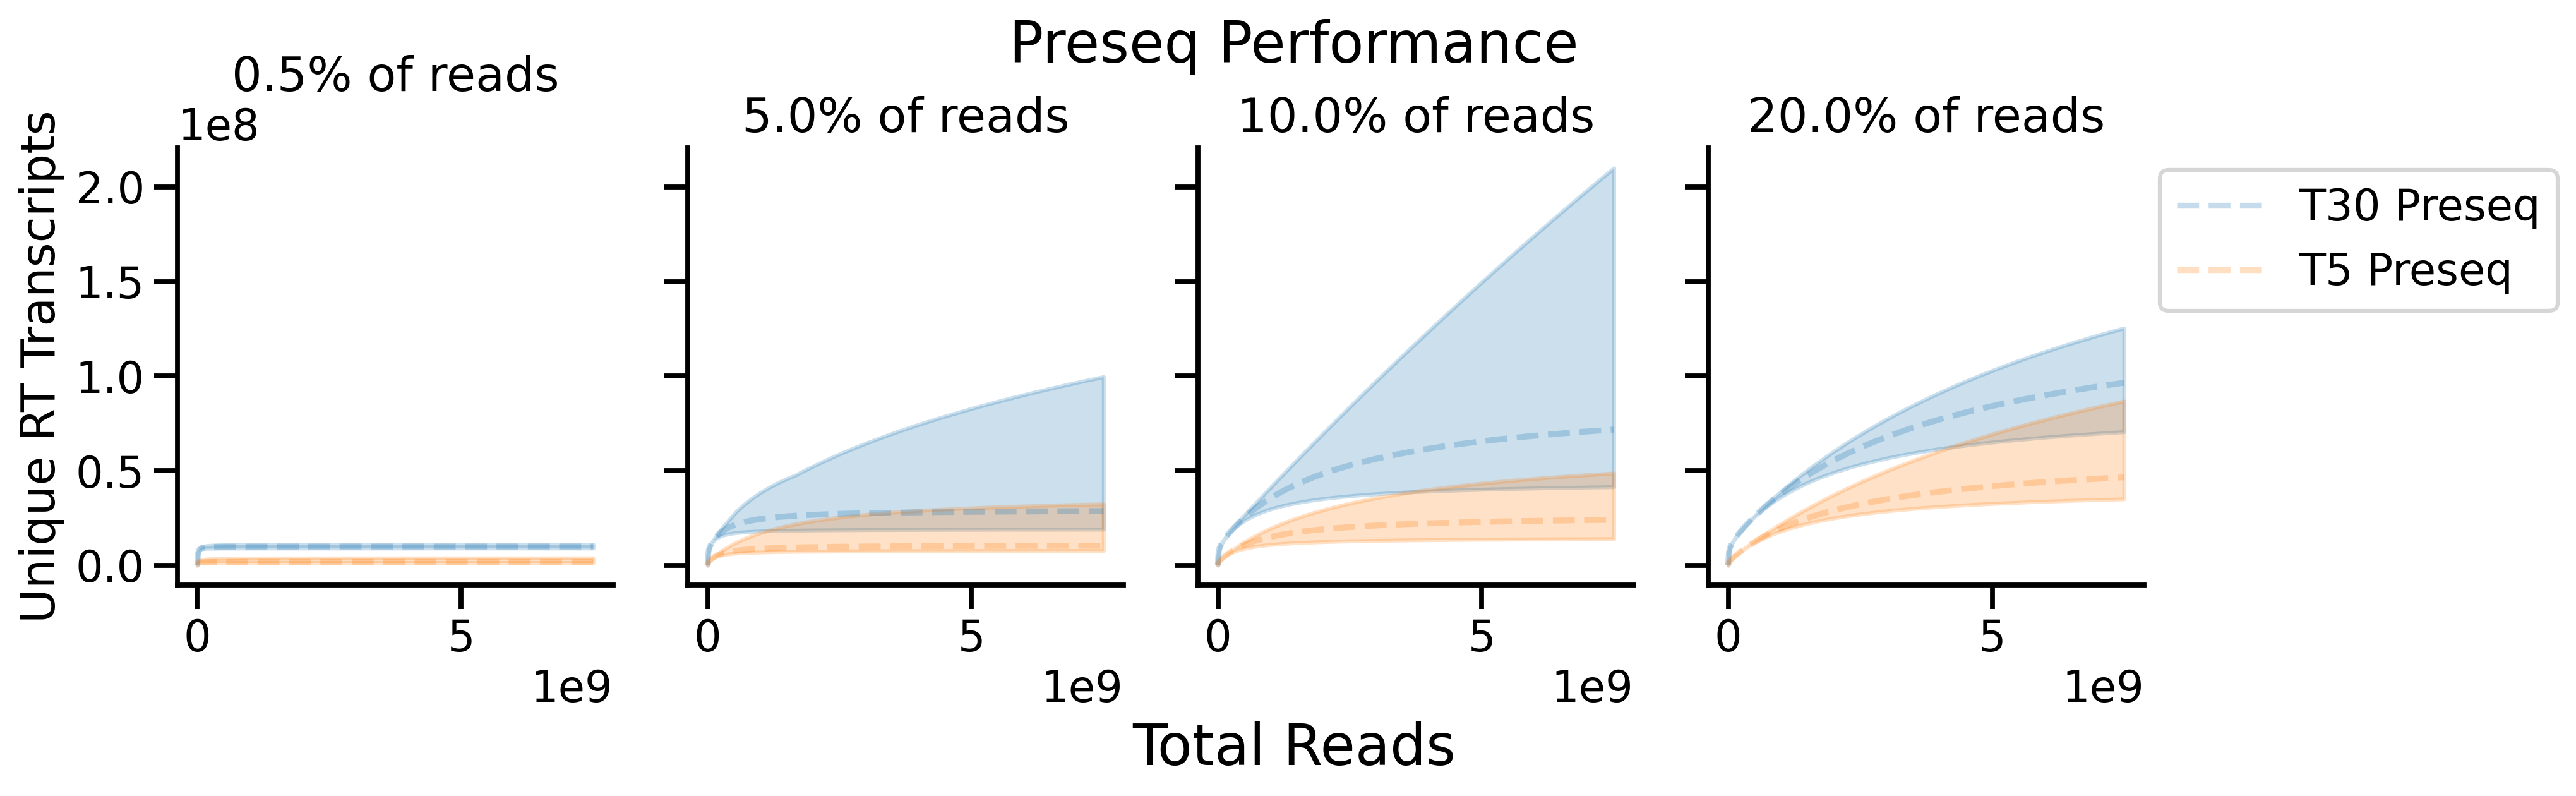

In [49]:
sns.set_context('talk')

fig, axes = plt.subplots(1, 4, figsize=(14, 4), dpi=300, sharey = True, sharex = True)
for ax, chunks in zip(axes, [200, 20, 10, 5]):
    ax = plot_preseq_comparison(chunks, False, fig, ax)
    if chunks != 5:
        ax.legend_.remove()
    else:
        ax.legend(bbox_to_anchor = (2,1))
    ax.set_xlabel("")
plt.tight_layout()
fig.supxlabel("Total Reads", y = -0.02)
fig.suptitle("Preseq Performance")

Text(0.5, 0.98, 'Preseq Performance')

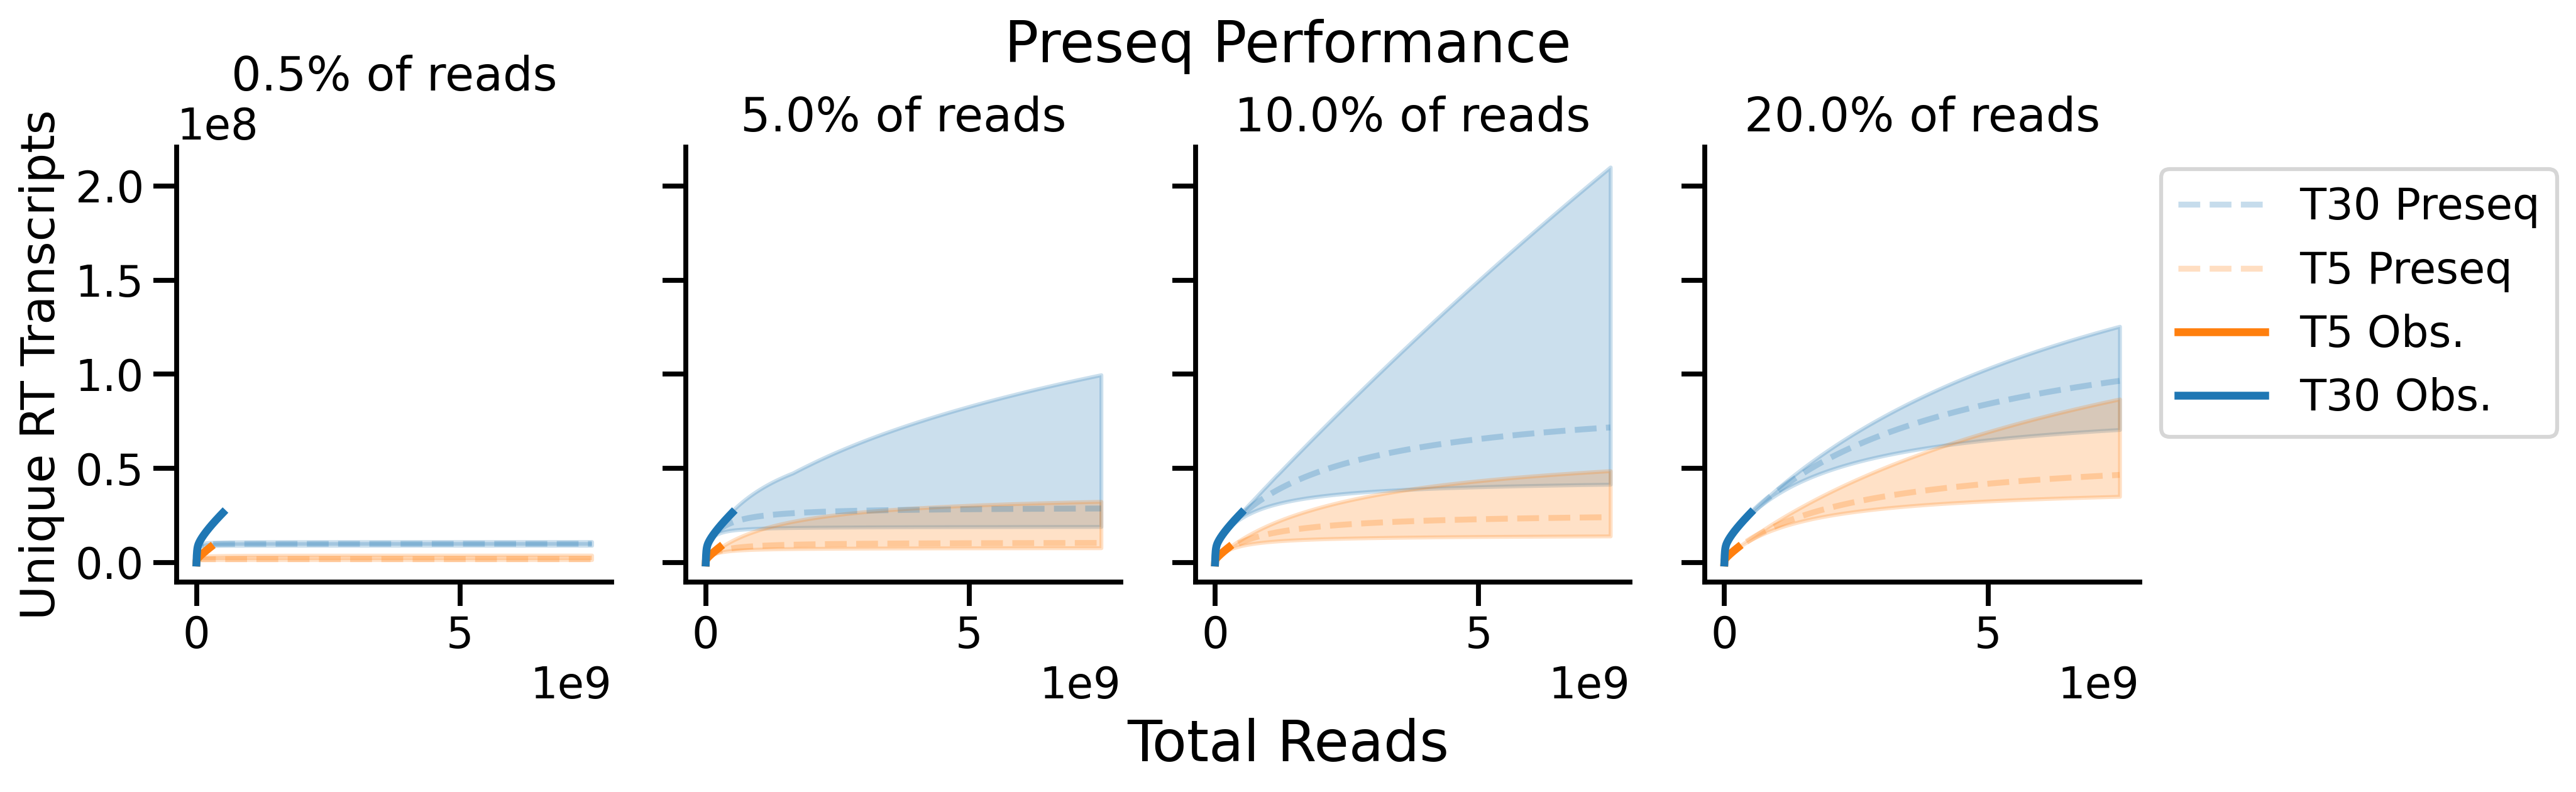

In [51]:
sns.set_context('talk')

fig, axes = plt.subplots(1, 4, figsize=(14, 4), dpi=300, sharey = True, sharex = True)
for ax, chunks in zip(axes, [200, 20, 10, 5]):
    ax = plot_preseq_comparison(chunks, True, fig, ax)
    if chunks != 5:
        ax.legend_.remove()
    else:
        ax.legend(bbox_to_anchor = (1,1))
    ax.set_xlabel("")
plt.tight_layout()
fig.supxlabel("Total Reads", y = -0.02)
fig.suptitle("Preseq Performance")